## Conhecendo os dados

### Carreagndo os dados

In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/alura-cursos/classificacao_multiclasse/main/Dados/df_vinho.csv'
df = pd.read_csv(url)

In [3]:
df

,acidez fixa,acidez volátil,ácido cítrico,açúcar residual,cloretos,dióxido de enxofre livre,dióxido de enxofre total,densidade,pH,sulfatos,álcool,qualidade
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,mediano
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,mediano
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,mediano
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,mediano
4,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,mediano
...,...,...,...,...,...,...,...,...,...,...,...,...
1354,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,mediano
1355,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,mediano
1356,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,mediano
1357,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,mediano


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   acidez fixa                1359 non-null   float64
 1   acidez volátil             1359 non-null   float64
 2   ácido cítrico              1359 non-null   float64
 3   açúcar residual            1359 non-null   float64
 4   cloretos                   1359 non-null   float64
 5   dióxido de enxofre livre   1359 non-null   float64
 6   dióxido de enxofre total   1359 non-null   float64
 7   densidade                  1359 non-null   float64
 8   pH                         1359 non-null   float64
 9   sulfatos                   1359 non-null   float64
 10  álcool                     1359 non-null   float64
 11  qualidade                  1359 non-null   object 
dtypes: float64(11), object(1)
memory usage: 127.5+ KB


In [5]:
df['qualidade'].unique()

array(['mediano', 'bom', 'ruim'], dtype=object)

### Análise exploratória

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df['qualidade'].value_counts(normalize=True)*100

,proportion
qualidade,
mediano,81.824871
bom,13.539367
ruim,4.635762


### Distribuição das Variáveis Numéricas

Vamos visualizar a distribuição das demais variáveis numéricas para entender sua dispersão e identificar possíveis padrões.

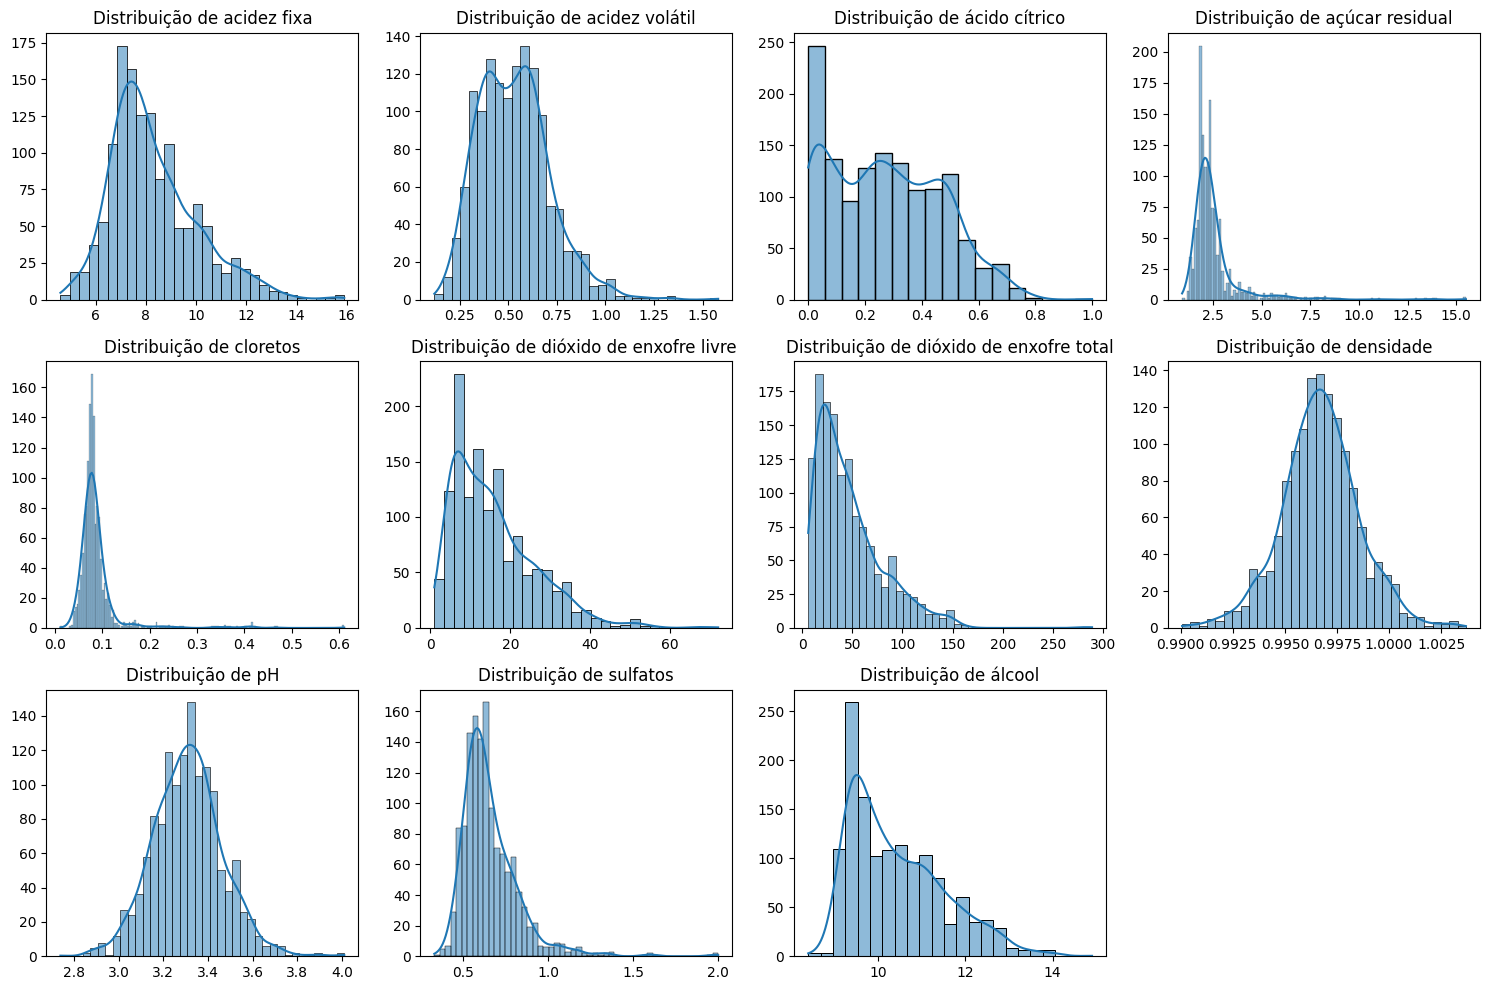

In [8]:
numerical_features = df.select_dtypes(include=['float64']).columns.tolist()

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribuição de {feature}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

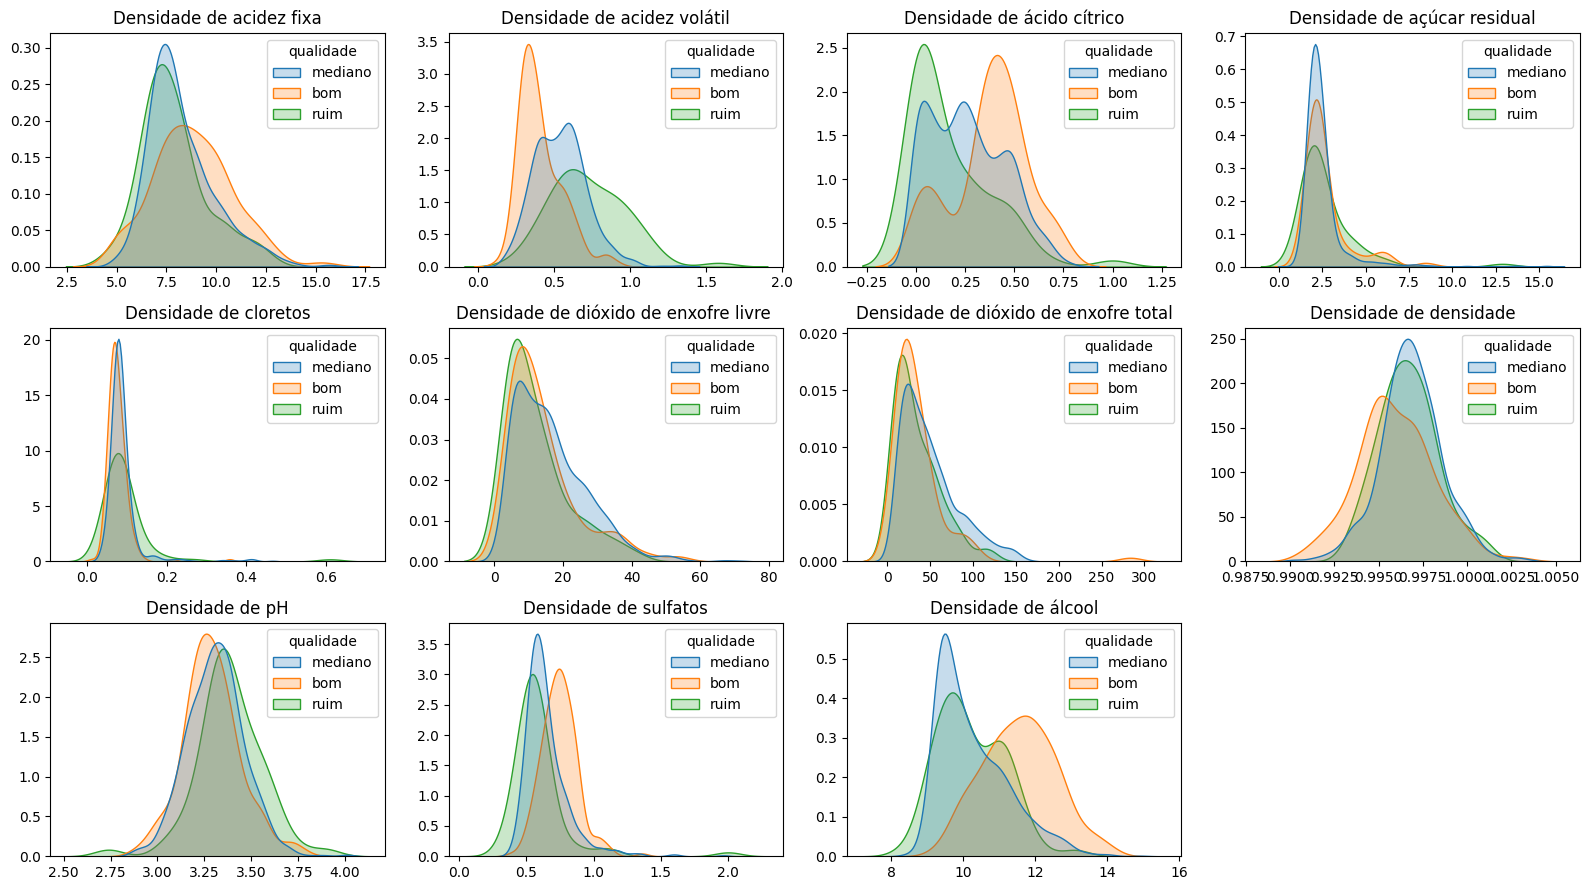

In [9]:
numerical_features = df.select_dtypes(include=['float64']).columns.tolist()

# Calculate the number of rows needed for the subplots
num_features = len(numerical_features)
num_cols = 4  # You can adjust this number
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 4, num_rows * 3))

for i, feature in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.kdeplot(data=df, x=feature, hue='qualidade', fill=True, common_norm=False)
    plt.title(f'Densidade de {feature}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

## Realizansdo o treianmento

### Preparando os dados

In [10]:
df['qualidade'].value_counts()

,count
qualidade,
mediano,1112
bom,184
ruim,63


In [12]:
from sklearn.preprocessing import LabelEncoder

# Inicializa o LabelEncoder
le = LabelEncoder()

# Aplica o LabelEncoder à coluna 'qualidade'
df['qualidade_encoded'] = le.fit_transform(df['qualidade'])

# Exibe os valores únicos da coluna original e da codificada para verificar
print("Valores originais da qualidade:", df['qualidade'].unique())
print("Valores codificados da qualidade:", df['qualidade_encoded'].unique())

# Exibe o mapeamento das classes
print("Mapeamento das classes:", list(le.classes_))
print("Valores numéricos correspondentes:", list(le.transform(le.classes_)))

Valores originais da qualidade: ['mediano' 'bom' 'ruim']
Valores codificados da qualidade: [1 0 2]
Mapeamento das classes: ['bom', 'mediano', 'ruim']
Valores numéricos correspondentes: [np.int64(0), np.int64(1), np.int64(2)]


### Separando os dados

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X = df.drop(columns=['qualidade', 'qualidade_encoded'])
y = df['qualidade_encoded']

In [15]:
X, X_teste, y, y_teste = train_test_split(X, y, test_size=0.15, stratify=y, random_state=0)
X_treino, X_val, y_treino, y_val = train_test_split(X, y, stratify=y, random_state=0)

## Treinando o modelo

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
modelo_rf = RandomForestClassifier(random_state=0, max_depth=10)
modelo_rf.fit(X_treino, y_treino)
print(f'Acuracia: {modelo_rf.score(X_treino, y_treino)}')
print(f'Acuracia: {modelo_rf.score(X_val, y_val)}')

Acuracia: 0.9722863741339491
Acuracia: 0.8442906574394463


In [18]:
y_pred = modelo_rf.predict(X_val)

## Avaliando o modelo

### Matriz de confusão

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

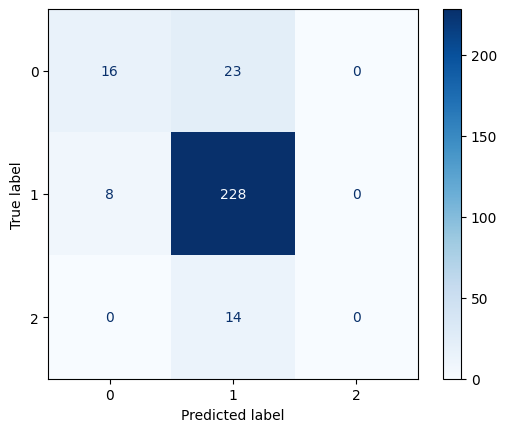

In [20]:
matriz_confusao = confusion_matrix(y_val, y_pred)

visualizacao = ConfusionMatrixDisplay(confusion_matrix = matriz_confusao, display_labels=modelo_rf.classes_)
visualizacao.plot(cmap='Blues')

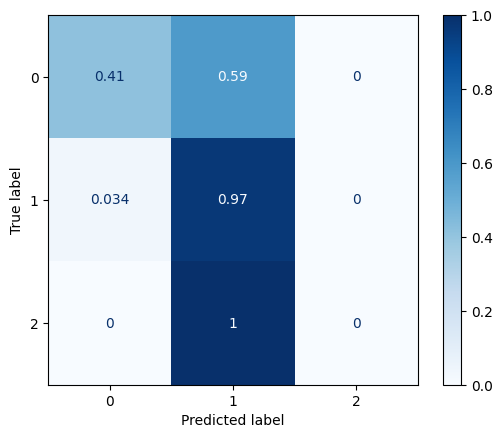

In [21]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', cmap='Blues');

### Relátorio de métricas

In [22]:
from sklearn.metrics import classification_report

In [23]:
report = classification_report(y_val, y_pred)
print('Relátorio de Classificação:\n', report)

Relátorio de Classificação:
               precision    recall  f1-score   support

           0       0.67      0.41      0.51        39
           1       0.86      0.97      0.91       236
           2       0.00      0.00      0.00        14

    accuracy                           0.84       289
   macro avg       0.51      0.46      0.47       289
weighted avg       0.79      0.84      0.81       289



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Superamostragem (Oversampling)

In [24]:
y_treino.value_counts()

,count
qualidade_encoded,
1,709
0,117
2,40


In [25]:
from imblearn.over_sampling import SMOTE

In [26]:
oversample = SMOTE(random_state=0)
X_balanceado, y_balanceado = oversample.fit_resample(X_treino, y_treino)

In [27]:
y_balanceado.value_counts()

,count
qualidade_encoded,
1,709
0,709
2,709


In [28]:
modelo = RandomForestClassifier(random_state=0, max_depth = 10)
modelo.fit(X_balanceado, y_balanceado)
y_pred_b = modelo.predict(X_val)

### Analisando as métricas após o balanceamento

              precision    recall  f1-score   support

           0       0.45      0.74      0.56        39
           1       0.92      0.75      0.83       236
           2       0.23      0.50      0.31        14

    accuracy                           0.74       289
   macro avg       0.53      0.67      0.57       289
weighted avg       0.82      0.74      0.77       289



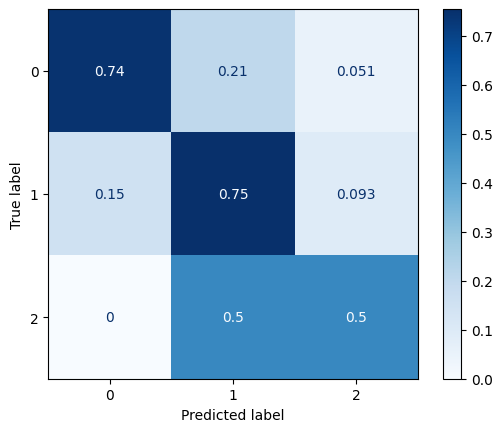

In [30]:
print(classification_report(y_val, y_pred_b))
print(ConfusionMatrixDisplay.from_predictions(y_val, y_pred_b, normalize='true', cmap='Blues'))

## Validando Modelo

### Pipeline para validação

In [31]:
from imblearn.pipeline import Pipeline as imbpipeline

In [32]:
modelo = RandomForestClassifier(random_state=0, max_depth = 10)
pipeline = imbpipeline([('Oversample', SMOTE()),('Floresta', modelo)])

In [33]:
from sklearn.model_selection import cross_validate, StratifiedKFold

In [34]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_resultado = cross_validate(pipeline, X, y, cv=skf, scoring='recall_weighted')
cv_resultado['test_score']

array([0.75324675, 0.75757576, 0.7012987 , 0.76623377, 0.75324675])

In [35]:
media =  cv_resultado['test_score'].mean()
desvio_padrao = cv_resultado['test_score'].std()
print(f'Intervalo de Confiança: [{media - (2*desvio_padrao)}, {min(media + (2*desvio_padrao), 1.0)}]')

Intervalo de Confiança: [0.7003105445693976, 0.792330148071295]


### Testando o modelo

              precision    recall  f1-score   support

           0       0.47      0.57      0.52        28
           1       0.90      0.83      0.86       167
           2       0.31      0.56      0.40         9

    accuracy                           0.78       204
   macro avg       0.56      0.65      0.59       204
weighted avg       0.81      0.78      0.79       204



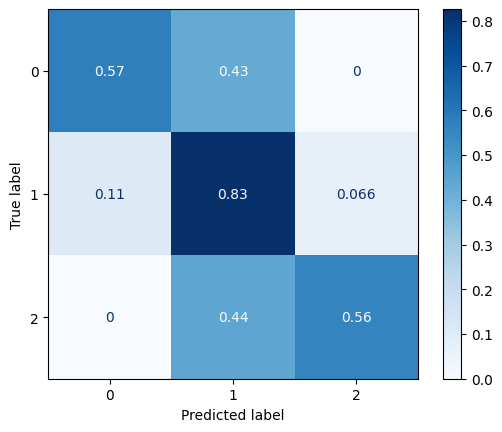

In [36]:
oversample = SMOTE(random_state=0)
X_balanceado, y_balanceado = oversample.fit_resample(X, y)
modelo = RandomForestClassifier(random_state=0, max_depth = 10)
modelo.fit(X_balanceado, y_balanceado)
y_pred = modelo.predict(X_teste)

print(classification_report(y_teste, y_pred))
ConfusionMatrixDisplay.from_predictions(y_teste, y_pred, normalize='true', cmap='Blues');